# 📊 Expense Tracker :

In [125]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [126]:
df=pd.read_csv("/content/expenses.csv")
df.head()

,Date,Amount,Category,Description
0,2024-01-01,250.0,Food,Lunch
1,2024-01-02,120.0,Transport,Bus
2,2024-01-03,NaN,Utilities,Electricity
3,2024-01-04,-300.0,Food,Dinner
4,2024-01-05,150.0,Entertainment,NaN


In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         90 non-null     object 
 1   Amount       84 non-null     float64
 2   Category     89 non-null     object 
 3   Description  85 non-null     object 
dtypes: float64(1), object(3)
memory usage: 2.9+ KB


In [128]:
df.isnull().sum()

,0
Date,0
Amount,6
Category,1
Description,5


In [129]:
df.dropna(inplace=True)
df

,Date,Amount,Category,Description
0,2024-01-01,250.0,Food,Lunch
1,2024-01-02,120.0,Transport,Bus
3,2024-01-04,-300.0,Food,Dinner
5,2024-01-06,200.0,Transport,Auto
6,2024-01-07,0.0,Food,Groceries
...,...,...,...,...
85,2024-03-26,-280.0,Transport,Auto
86,2024-03-27,500.0,Food,Groceries
87,2024-03-28,930.0,Utilities,Electricity
88,2024-03-29,140.0,Food,Snacks


In [130]:
for i in range(len(df)):
  if df["Amount"].iloc[i] <= 0:
    print("Invalid amount found at row :", i)

Invalid amount found at row : 2
Invalid amount found at row : 4
Invalid amount found at row : 19
Invalid amount found at row : 26
Invalid amount found at row : 53
Invalid amount found at row : 73


In [131]:
# Invalid Amount filled with 0
df.loc[df["Amount"] <= 0, "Amount"] = 0
df

,Date,Amount,Category,Description
0,2024-01-01,250.0,Food,Lunch
1,2024-01-02,120.0,Transport,Bus
3,2024-01-04,0.0,Food,Dinner
5,2024-01-06,200.0,Transport,Auto
6,2024-01-07,0.0,Food,Groceries
...,...,...,...,...
85,2024-03-26,0.0,Transport,Auto
86,2024-03-27,500.0,Food,Groceries
87,2024-03-28,930.0,Utilities,Electricity
88,2024-03-29,140.0,Food,Snacks


In [132]:

class ExpenseTracker:
    def __init__(self):
        self.expenses = []
    def add_expense(self, date, amount, category, description):
        self.expenses.append({
            "Date": date,
            "Amount": amount,
            "Category": category,
            "Description": description
        })
    def get_summary(self):
        df = pd.DataFrame(self.expenses)
        amounts = df["Amount"].values
        total = np.sum(amounts)
        average = np.mean(amounts)
        print("Total Spending:", total)
        print("Average Spending:", average)
        print("\nCategory-wise Spending:")
        categories = df["Category"].unique()
        for cat in categories:
            cat_amounts = df[df["Category"] == cat]["Amount"].values
            cat_total = np.sum(cat_amounts)
            print(cat, ":", cat_total)
    def filter_expenses(self, category):
        df = pd.DataFrame(self.expenses)
        filtered = df[df["Category"] == category]
        print("\nFiltered Expenses (" + category + "):")
        print(filtered)
    def generate_report(self):
        df = pd.DataFrame(self.expenses)
        print("\nExpense Report:")
        print(df)

In [133]:
# Get summary
tracker = ExpenseTracker()
for index, row in df.iterrows():
    tracker.add_expense(
        row["Date"],
        row["Amount"],
        row["Category"],
        row["Description"]
    )
tracker.get_summary()

Total Spending: 34360.0
Average Spending: 440.5128205128205

Category-wise Spending:
Food : 8440.0
Transport : 3120.0
Utilities : 12680.0
Invalid : 700.0
Entertainment : 9420.0


In [134]:
# Filtering expenses
tracker.filter_expenses("Food")


Filtered Expenses (Food):
          Date  Amount Category Description
0   2024-01-01   250.0     Food       Lunch
2   2024-01-04     0.0     Food      Dinner
4   2024-01-07     0.0     Food   Groceries
8   2024-01-12   350.0     Food  Restaurant
11  2024-01-17   500.0     Food   Groceries
13  2024-01-19   130.0     Food      Snacks
16  2024-01-22   320.0     Food      Dinner
17  2024-01-24   140.0     Food       Juice
20  2024-01-27   480.0     Food   Groceries
23  2024-01-31   300.0     Food       Lunch
25  2024-02-03   310.0     Food      Dinner
27  2024-02-06   470.0     Food   Groceries
29  2024-02-08   120.0     Food      Snacks
32  2024-02-11   360.0     Food  Restaurant
34  2024-02-13   190.0     Food    FastFood
37  2024-02-16   510.0     Food   Groceries
39  2024-02-18   140.0     Food      Snacks
42  2024-02-21   330.0     Food      Dinner
44  2024-02-23   150.0     Food       Juice
47  2024-02-26   490.0     Food   Groceries
49  2024-02-28   120.0     Food      Snacks
53  2

In [135]:
# Generating reports
tracker.generate_report()


Expense Report:
          Date  Amount       Category  Description
0   2024-01-01   250.0           Food        Lunch
1   2024-01-02   120.0      Transport          Bus
2   2024-01-04     0.0           Food       Dinner
3   2024-01-06   200.0      Transport         Auto
4   2024-01-07     0.0           Food    Groceries
..         ...     ...            ...          ...
73  2024-03-26     0.0      Transport         Auto
74  2024-03-27   500.0           Food    Groceries
75  2024-03-28   930.0      Utilities  Electricity
76  2024-03-29   140.0           Food       Snacks
77  2024-03-30   750.0  Entertainment        Movie

[78 rows x 4 columns]


In [136]:
# Using pandas to group expenses by category
category_group=df.groupby("Category")["Amount"].sum()
print("Total Expense per category :")
print(category_group)

Total Expense per category :
Category
Entertainment     9420.0
Food              8440.0
Invalid            700.0
Transport         3120.0
Utilities        12680.0
Name: Amount, dtype: float64


In [137]:
# Identifying top spending categories by pandas :
top_categories=category_group.nlargest(3)
print("\nTop 3 spending categories :")
print(top_categories)


Top 3 spending categories :
Category
Utilities        12680.0
Entertainment     9420.0
Food              8440.0
Name: Amount, dtype: float64


In [138]:
# Identifying top spending periods by pandas :
top_month_id=top_month.idxmax()
top_month_value=top_month.max()
print("Top spending month :", top_month_id)
print("Top spending month value :", top_month_value)

Top spending month : 2
Top spending month value : 12580.0


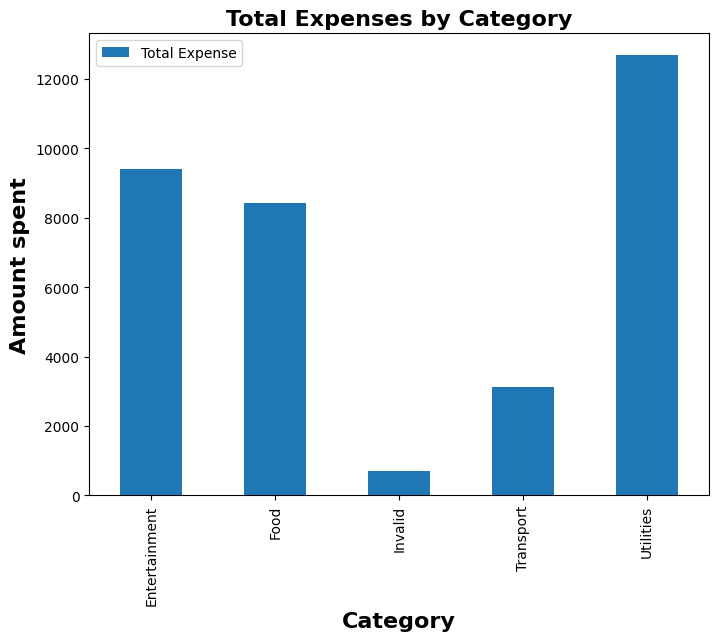

In [139]:
# Bar chart - Total expenses by category
category_sum=df.groupby("Category")["Amount"].sum()
plt.figure(figsize=(8, 6))
category_sum.plot(kind="bar", label="Total Expense")
plt.xlabel("Category", fontsize=16, fontweight="bold")
plt.ylabel("Amount spent", fontsize=16, fontweight="bold")
plt.title("Total Expenses by Category", fontsize=16, fontweight="bold")
plt.legend()
plt.show()

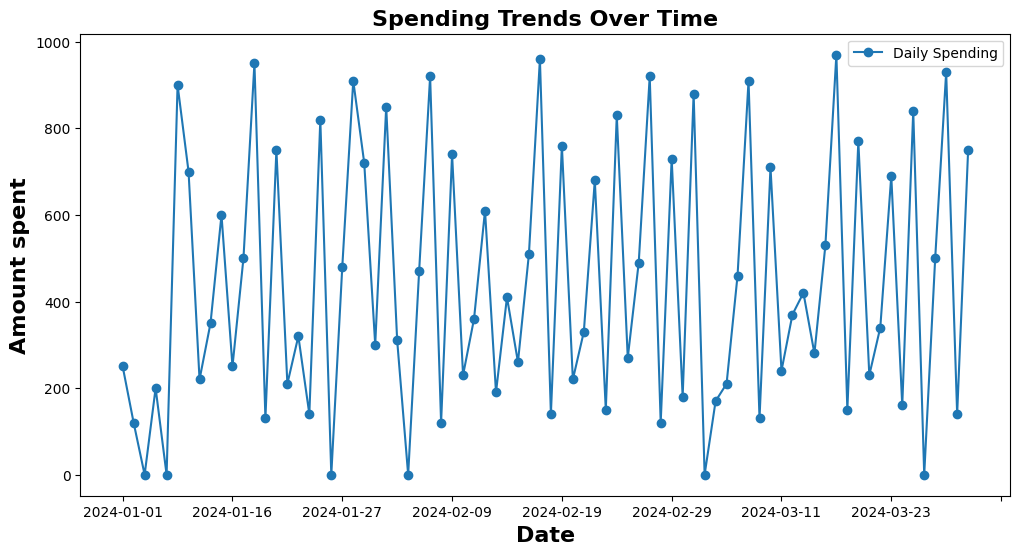

In [140]:
# Line chart - Spending trends over time
date_sum=df.groupby("Date")["Amount"].sum()
plt.figure(figsize=(12,6))
date_sum.plot(label="Daily Spending", marker="o")
plt.xlabel("Date", fontsize=16, fontweight="bold")
plt.ylabel("Amount spent", fontsize=16, fontweight="bold")
plt.title("Spending Trends Over Time", fontsize=16, fontweight="bold")
plt.legend()
plt.show()

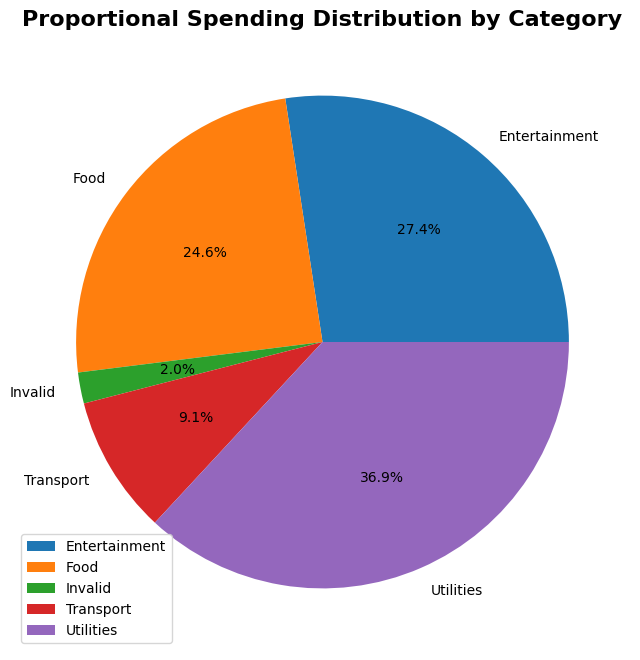

In [141]:
# Pie chart - Proportional spending distribution by category
plt.figure(figsize=(8, 8))
category_sum.plot(kind="pie", autopct="%1.1f%%")
plt.title("Proportional Spending Distribution by Category", fontsize=16, fontweight="bold")
plt.legend(category_sum.index)
plt.ylabel("")
plt.show()

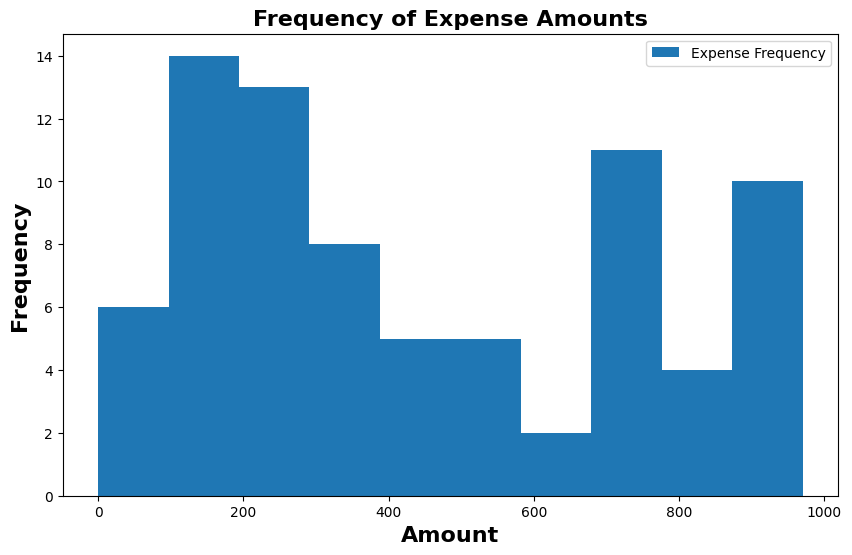

In [142]:
# Histogram - Frequency of expense amounts
plt.figure(figsize=(10,6))
plt.hist(df["Amount"], label= "Expense Frequency")
plt.title("Frequency of Expense Amounts", fontsize=16, fontweight="bold")
plt.xlabel("Amount", fontsize=16, fontweight="bold")
plt.ylabel("Frequency", fontsize=16, fontweight="bold")
plt.legend()
plt.show()